# Pooled harmonized observational analysis (CCM revision)

**Purpose (Reviewer 1, Major 3):** harmonize the shared covariate set across the three
observational cohorts (eICU-CRD, PMAP, MIMIC-IV), pool patients with a dataset indicator,
draw a single stratified 70/30 split, and repeat the HTE assessment
(CausalForestDML → CATE intervals, LRT for CATE×TTM interaction, IPW-weighted
interaction test, GATES) for **both outcomes**. Also produces:

- **Reviewer 1, Major 1** — IPW-weighted interaction test (pooled, and within each dataset's test rows)
- **Reviewer 1, Major 2** — L1 (lasso) S-learner sensitivity analysis with penalized treatment interactions
- **Reviewer 1, minor d** — collinearity filter (|r| > 0.7 with TTM) applied **uniformly**, including eICU-CRD
- **Reviewer 1, minor h** — GATES for the neurologic outcome (pooled level; per-dataset GATES-neuro lives in each dataset's DML notebook)

HYPERION is intentionally excluded (randomized design, non-shockable-only population).

**Exposure definitions** (unchanged from the paper): eICU-CRD `treatment_hypothermia`-derived
`Hypothermia` flag from treatment-table documentation; PMAP sustained <36°C for ≥12 consecutive
hours; MIMIC-IV cooling-device use ≥12 consecutive hours.

Run on the cluster from this folder:
```bash
jupyter nbconvert --to notebook --execute pooledObservationalAnalysis.ipynb \
  --output pooledObservationalAnalysis.ipynb --ExecutePreprocessor.timeout=-1
```
The final cell writes `pooled_analysis_results.csv` with the numbers for the
`[INSERT]` slots in `RESPONSE_TO_REVIEWERS.md`.


In [52]:
# CONFIG
SEED = 42
TEST_SIZE = 0.30
CORR_THRESHOLD = 0.7   # drop covariates with |corr| > 0.7 with TTM (uniform across datasets)
MIN_POSITIVE = 15      # drop binary covariates with < 15 positive cases (pooled)
N_GATES_GROUPS = 5
PS_CLIP = (0.05, 0.95) # propensity truncation, same as GATES in the paper

EICU_CSV  = '../eICU/eICUPredictorsDiag.csv'
PMAP_CSV  = '../pmap/PMAP_Predictors2.csv'
MIMIC_CSV = '../mimiciv/MIMIC_Predictors.csv'


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegressionCV
from xgboost import XGBClassifier
from econml.dml import CausalForestDML

np.random.seed(SEED)
pd.set_option('display.width', 160)


## 1. Per-dataset loading

Each loader replicates the preprocessing of the corresponding `*Util.py` **faithfully**
(same filters, same dropped columns, same temperature-column exclusions), except that:

1. both outcomes are kept (`mortality`, `neuro_favorable`) — outcome-specific row filters
   are deferred to analysis time (rows where the neurologic outcome is undefined carry NaN);
2. the `top_correlations.csv` collinearity filter (PMAP/MIMIC) is **not** applied here —
   the |r| > 0.7 filter is applied uniformly on the pooled data below (Reviewer 1, minor d);
3. treatment/outcome columns are renamed to canonical names (`TTM`, `mortality`,
   `neuro_favorable`).

Note: the PMAP util's temperature-column exclusion uses `and` where MIMIC uses `or`;
each is replicated as-is to match the published per-dataset cohorts.


In [54]:
UNSCORABLE = 'Unable to score due to medication'

def load_eicu(path=EICU_CSV):
    df = pd.read_csv(path)
    f = (df['LastMGCS'] != UNSCORABLE) & (~df['LastMGCS'].isna())
    f = f & (df['FirstMGCSTime'] != df['LastMGCSTime'])
    for c in ['FirstGCS', 'FirstMGCS', 'LastMGCS', 'LastGCS']:
        df.loc[df[c] == UNSCORABLE, c] = np.nan
    df.loc[df['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    df['gender'] = (df['gender'] == 'Male').astype(int)
    df.loc[f, 'LastMGCSPositive'] = (df.loc[f, 'LastMGCS'].astype(float) == 6).astype(int)
    gcs15 = (df['nurse_first_Motor'] != 6)
    df = df[f & gcs15 & ~df['Hypothermia'].isna()].copy()
    temp_cols = [c for c in df.columns if 'emp' in c]
    drop_cols = ['FirstGCS', 'FirstMGCS', 'LastMGCSTime', 'FirstMGCSTime', 'LastMGCS',
                 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime',
                 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource',
                 'patientunitstayid']
    df = df.drop(columns=[c for c in set(temp_cols + drop_cols) if c in df.columns])
    df = df.rename(columns={'Hypothermia': 'TTM', 'DeathAtDischarge': 'mortality',
                            'LastMGCSPositive': 'neuro_favorable'})  # keep 'gender' name so the
                            # male concept resolves; do NOT rename to 'male'
    df = df.select_dtypes(exclude=['object'])
    df['dataset'] = 'eICU'
    return df

def _load_epic_style(path, temp_rule):
    df = pd.read_csv(path)
    f = (df['first_mGCS_time'] != df['last_mGCS_time'])
    df.loc[df['death_at_disch'] == 1, 'last_mGCS'] = 1
    df.loc[f, 'LastMGCSPositive'] = (df.loc[f, 'last_mGCS'].astype(float) == 6).astype(int)
    gcs15 = (df['first_mGCS'] != 6)
    df = df[gcs15 & ~df['hypothermia'].isna()].copy()
    temp_cols = [c for c in df.columns if temp_rule(c)]
    # KEEP first_mGCS: baseline motor GCS is the dominant severity confounder for both TTM
    # assignment and mortality. Dropping it (previous bug) left residual confounding that
    # surfaced as spurious 'TTM harms the sick' HTE in the pooled mortality analysis.
    drop_cols = ['last_mGCS_time', 'first_mGCS_time', 'last_mGCS']
    df = df.drop(columns=[c for c in set(temp_cols + drop_cols) if c in df.columns])
    df = df.rename(columns={'hypothermia': 'TTM', 'death_at_disch': 'mortality',
                            'LastMGCSPositive': 'neuro_favorable'})
    df = df.select_dtypes(exclude=['object'])
    return df

def load_pmap(path=PMAP_CSV):
    # PMAP util: 'emp' in x AND x startswith 'dx_' (replicated as-is)
    df = _load_epic_style(path, lambda c: ('emp' in c) and (c[0:3] == 'dx_'))
    df['dataset'] = 'PMAP'
    return df

def load_mimic(path=MIMIC_CSV):
    # MIMIC util: 'emp' in x OR x startswith 'dx_'
    df = _load_epic_style(path, lambda c: ('emp' in c) or (c[0:3] == 'dx_'))
    df['dataset'] = 'MIMIC-IV'
    return df

frames = {'eICU': load_eicu(), 'PMAP': load_pmap(), 'MIMIC-IV': load_mimic()}
for name, d in frames.items():
    print(f"{name:9s} n={len(d):5d}  TTM={int(d['TTM'].sum()):4d} ({d['TTM'].mean():.1%})  "
          f"mortality={d['mortality'].mean():.1%}  neuro defined={d['neuro_favorable'].notna().mean():.1%}  "
          f"raw covariates={d.shape[1]-4}")


/local/mbranda1/3981445/ipykernel_3854165/2163122735.py:4: DtypeWarning: Columns (2188,2190) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


eICU      n= 1842  TTM= 608 (33.0%)  mortality=54.3%  neuro defined=100.0%  raw covariates=2870
PMAP      n= 1412  TTM= 666 (47.2%)  mortality=66.0%  neuro defined=91.3%  raw covariates=22657
MIMIC-IV  n=  611  TTM= 280 (45.8%)  mortality=64.2%  neuro defined=91.7%  raw covariates=7590


## 2. Concept-based harmonization (fuzzy-matched to the DML selected columns)

The datasets name the same clinical variable completely differently
(`nurse_first_Heart Rate` vs `flo_first_r_ed_pre-arrival_pulse_(heart_rate)` vs
`chart_first_heart_rate`), so a raw name intersection collapses to almost nothing. Instead we
take the **curated feature lists actually used by each dataset's `*AnalysisDML` notebook**
(`CURATED` below, copied from those notebooks) and fuzzy-match each column onto a canonical
clinical concept — the same `concept_map` idea already used in the MIMIC notebook.

Rhythm is included where documented: eICU (initial-rhythm VF/VT/PEA/asystole), PMAP
(asystole/PEA/VF ED flags), MIMIC-IV (ICD `long_title_ventricular_fibrillation` — a shockable
proxy only). Concepts present in ≥ `MIN_CONCEPT_DATASETS` datasets enter the pool.

**Review the printed resolution table after the first run** and correct any mis-match by
editing `CONCEPTS`/`CURATED`, then re-run (lab convention: read executed output first).


In [55]:
RESERVED = ['TTM', 'mortality', 'neuro_favorable', 'dataset']
MIN_CONCEPT_DATASETS = 3      # require a concept in ALL datasets -> no structural (whole-dataset)
                             # missingness -> no cross-dataset imputation leakage. Concepts in
                             # only 2/3 (e.g. rhythm_pea/asystole, absent in MIMIC) are examined
                             # per-dataset instead (perDatasetSensitivity.ipynb), not pooled.

import re
from difflib import SequenceMatcher

def normalize(s):
    s = str(s).lower()
    s = s.replace('fio2', 'fraction_inspired_oxygen').replace('o2', 'oxygen')
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

# Curated feature lists copied from each dataset's *AnalysisDML notebook (the 'columns' the
# models actually train on). Only clinically meaningful entries are kept here; matcher ignores
# anything that doesn't resolve to a concept.
CURATED = {
 'eICU': ['gender','age','bmi',
    'nurse_first_Non-Invasive BP Systolic','nurse_first_Non-Invasive BP Diastolic',
    'nurse_first_Non-Invasive BP Mean','nurse_first_Heart Rate','nurse_first_O2 Saturation',
    'lab_first_Respiratory Rate','lab_first_FiO2','nurse_first_GCS Total','nurse_first_Motor',
    'nurse_first_QTc','lab_first_pH','lab_first_paO2','lab_first_paCO2','lab_first_bicarbonate',
    'lab_first_lactate','lab_first_WBC x 1000','lab_first_Hgb','lab_first_platelets x 1000',
    'lab_first_sodium','lab_first_potassium','lab_first_BUN','lab_first_creatinine',
    'lab_first_calcium','lab_first_magnesium','lab_first_glucose','lab_first_troponin - T',
    'diagnosis_initial rhythm: ventricular fibrillation',
    'diagnosis_initial rhythm: ventricular tachycardia',
    'diagnosis_initial rhythm: pulseless electrical activity',
    'diagnosis_initial rhythm: asystole'],
 'PMAP': ['gender','age','first_mGCS','flo_first_r_cpn_glasgow_coma_scale_score',
    'flo_first_bp_systolic','flo_first_bp_diastolic','flo_first_r_map',
    'flo_first_r_ed_pre-arrival_pulse_(heart_rate)','flo_first_r_sao2','flo_first_r_fio2',
    'flo_first_r_sofa_score','flo_first_r_bmi','flo_first_r_pao2','flo_first_r_paco2',
    'flo_first_r_resp_ph','lab_first_lactate','lab_first_troponin','lab_first_hemoglobin',
    'lab_first_platelet_count','lab_first_creatinine,whole_blood','lab_first_glucose,whole_blood',
    'lab_first_potassium,whole_blood','lab_first_sodium,whole_blood','lab_first_calcium,_serum',
    'lab_first_magnesium','lab_first_jhm_ip_qtc_ainterval_(sec)',
    'asystole','pea','VF'],
 'MIMIC-IV': ['gender','age','bmi','first_mGCS',
    'chart_first_heart_rate','chart_first_o2_saturation_pulseoxymetry','chart_first_respiratory_rate',
    'chart_first_fio2_(ch)','chart_first_non_invasive_blood_pressure_systolic',
    'chart_first_non_invasive_blood_pressure_diastolic','chart_first_non_invasive_blood_pressure_mean',
    'chart_first_ph_(arterial)','chart_first_arterial_o2_pressure','chart_first_arterial_co2_pressure',
    'chart_first_lactic_acid','chart_first_wbc','chart_first_hemoglobin','lab_first_platelet_count',
    'chart_first_sodium_(serum)','lab_first_potassium_(serum)','chart_first_bun',
    'chart_first_creatinine_(serum)','chart_first_calcium_non-ionized','chart_first_magnesium',
    'chart_first_glucose_(serum)','lab_first_troponin-t','chart_first_qtc',
    'long_title_ventricular_fibrillation'],
}

# Canonical concept -> ordered alias list (most specific first). Temperature intentionally
# excluded (dropped upstream as it overlaps TTM). Rhythm concepts last.
CONCEPTS = {
 'age': ['age','anchor age'],
 'male': ['gender','sex','male'],
 'bmi': ['bmi','body mass index'],
 'sbp': ['non invasive blood pressure systolic','bp systolic','systolic'],
 'dbp': ['non invasive blood pressure diastolic','bp diastolic','diastolic'],
 'map': ['non invasive blood pressure mean','map','mean arterial'],
 'heart_rate': ['heart rate','pulse heart rate','pre arrival pulse heart rate'],
 'spo2': ['oxygen saturation','sao2','spo2','saturation pulseoxymetry'],
 'resp_rate': ['respiratory rate'],
 'fio2': ['fraction inspired oxygen','fio2'],
 'gcs_total': ['gcs total','glasgow coma scale score','glasgow coma scale total'],
 'gcs_motor': ['motor','first mgcs','mgcs'],
 'qtc': ['qtc'],
 'ph': ['ph arterial','resp ph','ph'],
 'pao2': ['arterial oxygen pressure','pao2'],
 'paco2': ['arterial co2 pressure','paco2'],
 'bicarbonate': ['bicarbonate'],
 'lactate': ['lactate','lactic acid'],
 'wbc': ['wbc','white blood cell'],
 'hemoglobin': ['hemoglobin','hgb'],
 'platelets': ['platelet count','platelets'],
 'sodium': ['sodium'],
 'potassium': ['potassium'],
 'bun': ['bun','blood urea nitrogen'],
 'creatinine': ['creatinine'],
 'calcium': ['calcium serum','calcium non ionized','calcium'],
 'magnesium': ['magnesium'],
 'glucose': ['glucose'],
 'troponin_t': ['troponin t','troponin'],
 'sofa': ['sofa score'],
 'rhythm_vf': ['initial rhythm ventricular fibrillation','ventricular fibrillation','vf'],
 'rhythm_vt': ['initial rhythm ventricular tachycardia','ventricular tachycardia'],
 'rhythm_pea': ['initial rhythm pulseless electrical activity','pulseless electrical activity','pea'],
 'rhythm_asystole': ['initial rhythm asystole','asystole'],
}

def resolve(aliases, cand_norm):
    """cand_norm: {normalized_name: original}. Return (original_col, how) or (None,None)."""
    # 1) exact normalized alias match, in priority order
    for a in aliases:
        na = normalize(a)
        if na in cand_norm:
            return cand_norm[na], 'exact'
    # 2) substring (alias inside column), prefer the tightest (shortest) column
    subs = []
    for a in aliases:
        na = normalize(a)
        for cn, orig in cand_norm.items():
            if na and (na in cn.split() or (' ' + na + ' ') in (' ' + cn + ' ') or na in cn):
                subs.append((len(cn), orig))
    if subs:
        return sorted(subs)[0][1], 'substring'
    # 3) fuzzy fallback
    best, best_col = 0.0, None
    for a in aliases:
        na = normalize(a)
        for cn, orig in cand_norm.items():
            r = SequenceMatcher(None, na, cn).ratio()
            if r > best:
                best, best_col = r, orig
    return (best_col, f'fuzzy {best:.2f}') if best >= 0.60 else (None, None)

harmonized, resolution = {}, []
for name, d in frames.items():
    cand = [c for c in CURATED[name] if c in d.columns]
    cand_norm = {normalize(c): c for c in cand}
    ren = {}
    for concept, aliases in CONCEPTS.items():
        col, how = resolve(aliases, cand_norm)
        resolution.append({'concept': concept, 'dataset': name, 'column': col, 'how': how})
        if col is not None and col not in ren:
            ren[col] = concept
    dd = d.rename(columns=ren)
    dd = dd.loc[:, ~dd.columns.duplicated()]
    keep = RESERVED + [c for c in CONCEPTS if c in dd.columns]
    harmonized[name] = dd[[c for c in keep if c in dd.columns]]

res_df = pd.DataFrame(resolution)
avail = res_df[res_df['column'].notna()].groupby('concept')['dataset'].nunique()
CONCEPT_COLS = [c for c in CONCEPTS if avail.get(c, 0) >= MIN_CONCEPT_DATASETS]

print("Concept resolution (column matched per dataset):")
print(res_df.pivot(index='concept', columns='dataset', values='column').fillna('--').to_string())
print(f"\nConcepts resolved in >= {MIN_CONCEPT_DATASETS} datasets -> {len(CONCEPT_COLS)}: {CONCEPT_COLS}")
unresolved = [c for c in CONCEPTS if avail.get(c, 0) < MIN_CONCEPT_DATASETS]
if unresolved:
    print(f"Below threshold (excluded): {unresolved}")


Concept resolution (column matched per dataset):
dataset                                                   MIMIC-IV                                           PMAP                                                     eICU
concept                                                                                                                                                                   
age                                                            age                                            age                                                      age
bicarbonate                                                     --                                             --                                    lab_first_bicarbonate
bmi                                                             --                                flo_first_r_bmi                                                      bmi
bun                                                chart_first_bun                              

## 3. Pooling and uniform feature filters

Pool on the harmonized concepts, add dataset indicator dummies (site-effect absorption),
then apply — uniformly, including eICU-CRD —

- rare-binary filter: binary concepts with < 15 positive cases in the pool;
- positivity/collinearity filter: concepts with |r| > 0.7 with `TTM`.

With `MIN_CONCEPT_DATASETS = 3` every pooled concept exists in all datasets, so there is no
structural (whole-dataset) missingness. Remaining sporadic missingness is imputed **within each
dataset** (fit on that dataset's training rows only) so no signal leaks across datasets — this
is what makes the pooled CATE clean rather than a dataset proxy.


In [56]:
pooled = pd.concat([harmonized[n] for n in frames], axis=0, ignore_index=True)
for c in CONCEPT_COLS:                       # ensure every kept concept is a column
    if c not in pooled.columns:
        pooled[c] = np.nan

ds_dummies = pd.get_dummies(pooled['dataset'], prefix='ds', drop_first=True).astype(int)
pooled = pd.concat([pooled, ds_dummies], axis=1)
DS_COLS = list(ds_dummies.columns)

# rare-binary filter
binary = [c for c in CONCEPT_COLS if pooled[c].dropna().nunique() == 2]
rare = [c for c in binary if pooled[c].sum(skipna=True) < MIN_POSITIVE]

# uniform treatment-collinearity filter (Reviewer 1, minor d)
corr_t = pooled[CONCEPT_COLS].corrwith(pooled['TTM']).abs()
collinear = [c for c in CONCEPT_COLS if corr_t.get(c, 0) > CORR_THRESHOLD]

COVARIATES = [c for c in CONCEPT_COLS if c not in set(rare) | set(collinear)]
print(f"Pooled n = {len(pooled)}  (TTM {pooled['TTM'].mean():.1%})")
print(f"Harmonized concepts {len(CONCEPT_COLS)} -> dropped {len(rare)} rare-binary, "
      f"{len(collinear)} collinear with TTM -> {len(COVARIATES)} + {len(DS_COLS)} dataset dummies")
print('Pooled covariates:', COVARIATES)
if collinear:
    print('Collinear with TTM (|r|>0.7):', collinear)
rhythm_kept = [c for c in COVARIATES if c.startswith('rhythm_')]
print('Rhythm variables in pooled model:', rhythm_kept or 'NONE')


Pooled n = 3865  (TTM 40.2%)
Harmonized concepts 21 -> dropped 0 rare-binary, 0 collinear with TTM -> 21 + 2 dataset dummies
Pooled covariates: ['age', 'male', 'sbp', 'dbp', 'map', 'heart_rate', 'spo2', 'fio2', 'gcs_motor', 'ph', 'pao2', 'paco2', 'hemoglobin', 'platelets', 'sodium', 'potassium', 'creatinine', 'calcium', 'magnesium', 'glucose', 'troponin_t']
Rhythm variables in pooled model: NONE


## 4. Analysis machinery

Split → preprocess (fit on train only) → CausalForestDML (paper's nuisance settings) →
CATE intervals → LRT (manuscript form: `logit(Y) ~ T + CATE + T×CATE`) → IPW-weighted
interaction test → GATES with IPW.

The weighted-test and GATES functions here are self-contained; the same two functions can
be pasted into each per-dataset `*AnalysisDML.ipynb` to produce the per-dataset weighted
LRT promised in the response letter (Reviewer 1, Major 1).


In [57]:
def split_and_preprocess(outcome):
    d = pooled.dropna(subset=[outcome]).reset_index(drop=True).copy()
    y = d[outcome].astype(int)
    T = d['TTM'].astype(int)
    ds = d['dataset']
    idx = np.arange(len(d))
    tr, te = train_test_split(idx, test_size=TEST_SIZE, random_state=SEED,
                              stratify=pd.concat([y, T, ds], axis=1))
    tr_set = set(tr)

    Xc = d[COVARIATES].astype(float).copy()
    # WITHIN-DATASET KNN imputation: fit on each dataset's TRAIN rows only, apply to that
    # dataset's rows. No cross-dataset borrowing -> no dataset signal leaks into the CATE.
    for name in ds.unique():
        rows = np.where((ds == name).values)[0]
        rows_tr = np.array([i for i in rows if i in tr_set])
        imp = KNNImputer(n_neighbors=10, keep_empty_features=True)
        imp.fit(Xc.iloc[rows_tr])
        Xc.iloc[rows] = imp.transform(Xc.iloc[rows])

    num = [c for c in COVARIATES if d[c].dropna().nunique() > 2]
    scaler = StandardScaler().fit(Xc.iloc[tr][num])
    Xc[num] = scaler.transform(Xc[num])

    X = pd.concat([Xc, d[DS_COLS].astype(float)], axis=1)
    return (X.iloc[tr], X.iloc[te], T.iloc[tr], T.iloc[te],
            y.iloc[tr], y.iloc[te], ds.iloc[tr], ds.iloc[te])


def fit_causal_forest(X_tr, T_tr, y_tr):
    cf = CausalForestDML(
        model_y=XGBClassifier(max_depth=3, n_estimators=50),
        model_t=XGBClassifier(max_depth=2, n_estimators=20),
        discrete_treatment=True, discrete_outcome=True,
        random_state=SEED, n_jobs=-1)
    cf.fit(y_tr, T_tr, X=X_tr, cache_values=True)
    return cf


def cf_propensity(cf, X):
    preds = []
    for mc in cf.models_t:
        for mdl in mc:
            p = mdl.predict_proba(np.asarray(X))
            preds.append(p[:, 1] if p.ndim == 2 else np.ravel(p))
    return np.clip(np.mean(np.vstack(preds), axis=0), 1e-6, 1 - 1e-6)


In [58]:
def lrt_cate_interaction(y, T, cate):
    """Manuscript LRT: logit(Y) ~ T + CATE vs + T:CATE (chi2, 1 df)."""
    df = pd.DataFrame({'const': 1.0, 'T': np.asarray(T, float),
                       'cate': np.asarray(cate, float)})
    df['tx'] = df['T'] * df['cate']
    y = np.asarray(y, float)
    m0 = sm.Logit(y, df[['const', 'T', 'cate']]).fit(disp=False)
    m1 = sm.Logit(y, df[['const', 'T', 'cate', 'tx']]).fit(disp=False)
    lr = 2 * (m1.llf - m0.llf)
    return {'lr_stat': lr, 'p': chi2.sf(lr, 1)}


def ipw_interaction_test(y, T, cate, ps, clip=PS_CLIP):
    """IPW-weighted CATE x TTM interaction (Reviewer 1, Major 1).

    IPW weights (freq_weights) with a ROBUST sandwich covariance (cov_type='HC1') for the Wald
    test on the interaction. Using var_weights (the previous approach) treats the IPW weights as
    known precisions and understates the SE -> anti-conservative p-values; the robust SE is the
    correct inference for weighted estimation and is what should be reported."""
    T = np.asarray(T, float); y = np.asarray(y, float)
    ps = np.clip(np.asarray(ps, float), *clip)
    w = np.where(T == 1, 1.0 / ps, 1.0 / (1.0 - ps))
    df = pd.DataFrame({'const': 1.0, 'T': T, 'cate': np.asarray(cate, float)})
    df['tx'] = df['T'] * df['cate']
    fam = sm.families.Binomial()
    m1 = sm.GLM(y, df[['const', 'T', 'cate', 'tx']], family=fam,
                freq_weights=w).fit(cov_type='HC1')
    # naive (var_weights) Wald kept for comparison/transparency
    m1_naive = sm.GLM(y, df[['const', 'T', 'cate', 'tx']], family=fam, var_weights=w).fit()
    return {'wald_p': m1.pvalues['tx'], 'wald_p_naive': m1_naive.pvalues['tx']}


def run_gates(cate, y, T, ps, n_groups=N_GATES_GROUPS, title=''):
    """IPW-weighted GATES with joint F-test and Spearman monotonicity (paper method)."""
    ps = np.clip(np.asarray(ps, float), *PS_CLIP)
    d = pd.DataFrame({'y': np.asarray(y, float), 'T': np.asarray(T, float),
                      'cate': np.asarray(cate, float)})
    d['w'] = np.where(d['T'] == 1, 1 / ps, 1 / (1 - ps))
    d['g'] = pd.qcut(d['cate'], q=n_groups, labels=False, duplicates='drop') + 1
    rows = []
    for g, sub in d.groupby('g'):
        wls = sm.WLS(sub['y'], sm.add_constant(sub['T']), weights=sub['w']).fit()
        ci = wls.conf_int()
        rows.append({'group': int(g), 'n': len(sub), 'mean_cate': sub['cate'].mean(),
                     'gate': wls.params.iloc[1],
                     'ci_low': np.asarray(ci)[1, 0], 'ci_high': np.asarray(ci)[1, 1]})
    gdf = pd.DataFrame(rows)

    gd = pd.get_dummies(d['g'].astype(int), prefix='g', drop_first=True).astype(float)
    Xr = sm.add_constant(pd.concat([d[['T']], gd], axis=1))
    Xf = Xr.copy()
    for c in gd.columns:
        Xf[f'T_x_{c}'] = d['T'].values * gd[c].values
    mf = sm.WLS(d['y'], Xf, weights=d['w']).fit()
    mr = sm.WLS(d['y'], Xr, weights=d['w']).fit()
    f_stat, f_p, _ = mf.compare_f_test(mr)
    rho, rho_p = stats.spearmanr(gdf['group'], gdf['gate'])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(gdf['group'], gdf['gate'],
                yerr=[gdf['gate'] - gdf['ci_low'], gdf['ci_high'] - gdf['gate']],
                fmt='o-', capsize=5)
    ax.axhline(0, ls='--', color='gray')
    ax.set_xlabel('CATE quintile (1 = lowest predicted benefit)')
    ax.set_ylabel('GATE (IPW)')
    ax.set_title(f'GATES — {title}\nF p={f_p:.3f}, Spearman rho={rho:.2f} (p={rho_p:.3f})')
    plt.tight_layout()
    plt.savefig(f"gates_pooled_{title.lower().replace(' ', '_').replace('=', '')}.png", dpi=150)
    plt.show()
    return gdf, {'f_stat': f_stat, 'f_p': f_p, 'spearman_rho': rho, 'spearman_p': rho_p}


## 5. Pooled analysis — both outcomes

For each outcome: fit CausalForestDML on pooled train, evaluate on the pooled held-out
test set. Per-dataset weighted interaction tests use the pooled model's CATE and
propensity restricted to each dataset's test rows (complementary to — not a substitute
for — the per-dataset models in the dataset notebooks).


=== Hospital mortality: train n=2705, test n=1160 ===


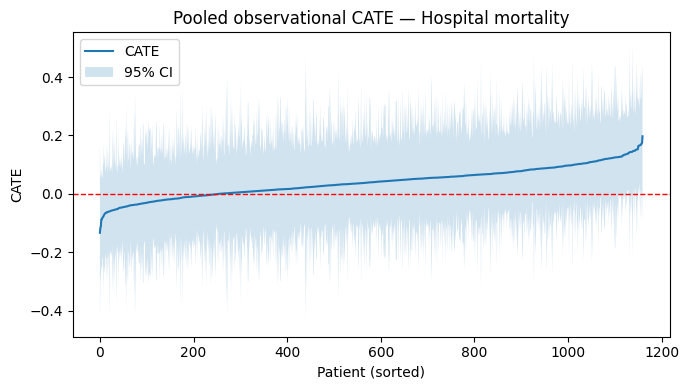

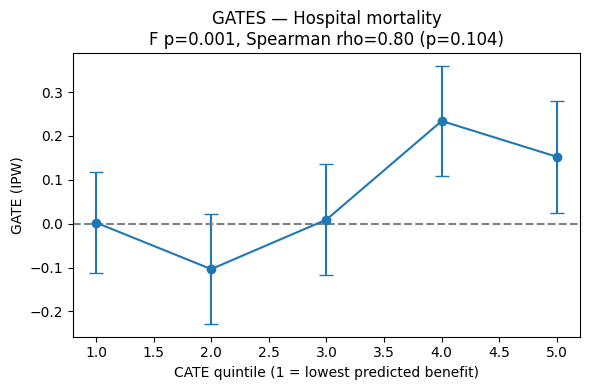

LRT (unweighted)      : chi2=7.193, p=0.0073
IPW interaction (robust Wald): p=0.0001  (naive var_weights Wald p=0.0001)
GATES: F p=0.0014, Spearman rho=0.80 (p=0.1041); CATE CIs crossing zero: 98.7%


,group,n,mean_cate,gate,ci_low,ci_high
0,1,232,-0.030,0.002,-0.113,0.118
1,2,232,0.011,-0.104,-0.228,0.021
2,3,232,0.040,0.009,-0.118,0.136
3,4,232,0.067,0.234,0.109,0.360
4,5,232,0.112,0.153,0.024,0.281


  PMAP      (test n= 424) IPW interaction Wald p=0.5111
  eICU      (test n= 552) IPW interaction Wald p=0.0030
  MIMIC-IV  (test n= 184) IPW interaction Wald p=0.0379


In [59]:
RESULTS = []

def run_pooled(outcome, label):
    X_tr, X_te, T_tr, T_te, y_tr, y_te, ds_tr, ds_te = split_and_preprocess(outcome)
    print(f"=== {label}: train n={len(X_tr)}, test n={len(X_te)} ===")
    cf = fit_causal_forest(X_tr, T_tr, y_tr)

    cate_te = np.ravel(cf.effect(X_te))
    lo, hi = cf.effect_interval(X_te, alpha=0.05)
    lo, hi = np.ravel(lo), np.ravel(hi)
    pct_ci_cross_zero = float(np.mean((lo < 0) & (hi > 0)))

    order = np.argsort(cate_te)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(cate_te[order], label='CATE')
    ax.fill_between(range(len(order)), lo[order], hi[order], alpha=0.2, label='95% CI')
    ax.axhline(0, color='red', ls='--', lw=1)
    ax.set_xlabel('Patient (sorted)'); ax.set_ylabel('CATE')
    ax.set_title(f'Pooled observational CATE — {label}')
    ax.legend(); plt.tight_layout()
    plt.savefig(f"cate_pooled_{label.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

    ps_te = cf_propensity(cf, X_te)
    lrt = lrt_cate_interaction(y_te, T_te, cate_te)
    ipw = ipw_interaction_test(y_te, T_te, cate_te, ps_te)
    gdf, gates = run_gates(cate_te, y_te, T_te, ps_te, title=label)

    print(f"LRT (unweighted)      : chi2={lrt['lr_stat']:.3f}, p={lrt['p']:.4f}")
    print(f"IPW interaction (robust Wald): p={ipw['wald_p']:.4f}  "
          f"(naive var_weights Wald p={ipw['wald_p_naive']:.4f})")
    print(f"GATES: F p={gates['f_p']:.4f}, Spearman rho={gates['spearman_rho']:.2f} "
          f"(p={gates['spearman_p']:.4f}); CATE CIs crossing zero: {pct_ci_cross_zero:.1%}")
    display(gdf.round(3))

    RESULTS.append({'analysis': 'pooled', 'outcome': label,
                    'n_train': len(X_tr), 'n_test': len(X_te),
                    'lrt_p': lrt['p'], 'ipw_wald_p': ipw['wald_p'],
                    'ipw_wald_p_naive': ipw['wald_p_naive'], 'gates_f_p': gates['f_p'],
                    'gates_spearman_rho': gates['spearman_rho'],
                    'gates_spearman_p': gates['spearman_p'],
                    'pct_cate_ci_cross_zero': pct_ci_cross_zero})

    # per-dataset weighted interaction on the pooled model (test rows only)
    for ds_name in ds_te.unique():
        m = (ds_te == ds_name).values
        try:
            r = ipw_interaction_test(np.asarray(y_te)[m], np.asarray(T_te)[m],
                                     cate_te[m], ps_te[m])
            print(f"  {ds_name:9s} (test n={m.sum():4d}) IPW interaction Wald p={r['wald_p']:.4f}")
            RESULTS.append({'analysis': f'per-dataset ({ds_name})', 'outcome': label,
                            'n_test': int(m.sum()), 'ipw_wald_p': r['wald_p'],
                            'ipw_wald_p_naive': r['wald_p_naive']})
        except Exception as e:
            print(f"  {ds_name}: weighted test failed ({e})")
    return cf

cf_mort = run_pooled('mortality', 'Hospital mortality')


=== Favorable neurologic (last mGCS=6): train n=2583, test n=1108 ===


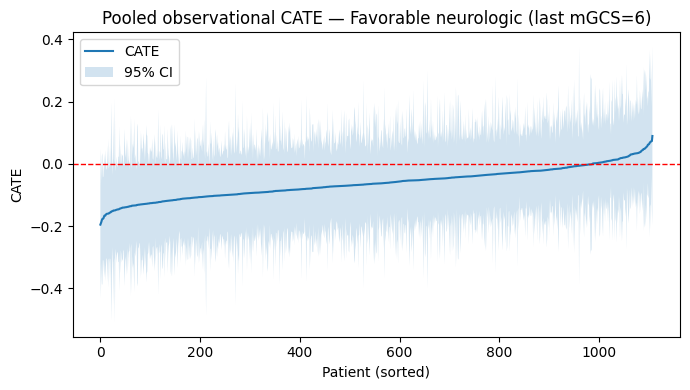

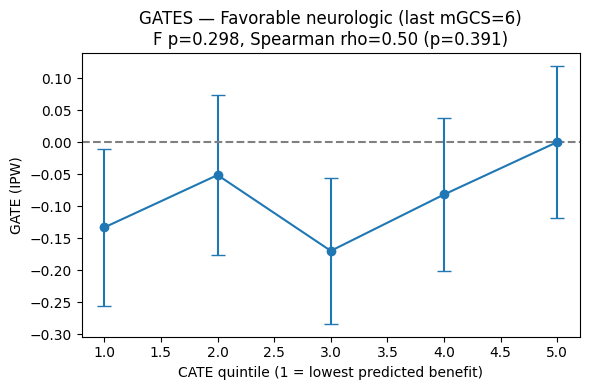

LRT (unweighted)      : chi2=2.140, p=0.1435
IPW interaction (robust Wald): p=0.1146  (naive var_weights Wald p=0.1066)
GATES: F p=0.2976, Spearman rho=0.50 (p=0.3910); CATE CIs crossing zero: 96.7%


,group,n,mean_cate,gate,ci_low,ci_high
0,1,222,-0.128,-0.133,-0.256,-0.010
1,2,221,-0.090,-0.051,-0.175,0.073
2,3,222,-0.063,-0.170,-0.283,-0.056
3,4,221,-0.035,-0.082,-0.200,0.037
4,5,222,0.008,0.000,-0.118,0.119


  eICU      (test n= 553) IPW interaction Wald p=0.1615
  MIMIC-IV  (test n= 168) IPW interaction Wald p=0.2086
  PMAP      (test n= 387) IPW interaction Wald p=0.9788


In [60]:
cf_neuro = run_pooled('neuro_favorable', 'Favorable neurologic (last mGCS=6)')

## 6. Lasso S-learner sensitivity (Reviewer 1, Major 2)

L1-penalized logistic S-learner on the pooled training set with design
`[X, T, X×T]` — every treatment interaction penalized. `C` chosen by 5-fold CV.
Reported: how many interaction coefficients survive the penalty (0 ⇒ no heterogeneity
signal survives regularization).


In [61]:
def lasso_slearner(outcome, label):
    X_tr, X_te, T_tr, T_te, y_tr, y_te, *_ = split_and_preprocess(outcome)
    Xd = X_tr.copy()
    Xd['TTM'] = np.asarray(T_tr, float)
    inter_cols = []
    for c in X_tr.columns:
        ic = f'{c}_x_TTM'
        Xd[ic] = Xd[c] * Xd['TTM']
        inter_cols.append(ic)
    clf = LogisticRegressionCV(penalty='l1', solver='saga', Cs=10, cv=5,
                               scoring='neg_log_loss', max_iter=5000,
                               n_jobs=-1, random_state=SEED)
    clf.fit(Xd, y_tr)
    coefs = pd.Series(clf.coef_[0], index=Xd.columns)
    nz = coefs[inter_cols][coefs[inter_cols] != 0]
    print(f"{label}: C={clf.C_[0]:.4g}; non-zero interaction coefficients: "
          f"{len(nz)}/{len(inter_cols)}")
    if len(nz):
        display(nz.sort_values(key=np.abs, ascending=False).head(15).round(4))
    RESULTS.append({'analysis': 'lasso S-learner', 'outcome': label,
                    'n_train': len(Xd), 'nonzero_interactions': len(nz),
                    'n_interactions': len(inter_cols), 'chosen_C': float(clf.C_[0])})
    return coefs

_ = lasso_slearner('mortality', 'Hospital mortality')
_ = lasso_slearner('neuro_favorable', 'Favorable neurologic (last mGCS=6)')


Hospital mortality: C=0.3594; non-zero interaction coefficients: 16/23


troponin_t_x_TTM    0.3730
hemoglobin_x_TTM   -0.2630
ds_eICU_x_TTM       0.2077
spo2_x_TTM          0.1678
dbp_x_TTM          -0.1660
age_x_TTM          -0.1625
sbp_x_TTM           0.1600
potassium_x_TTM     0.1341
glucose_x_TTM       0.1164
gcs_motor_x_TTM     0.0909
map_x_TTM           0.0896
heart_rate_x_TTM   -0.0762
sodium_x_TTM       -0.0477
paco2_x_TTM        -0.0433
ph_x_TTM            0.0360
dtype: float64

Favorable neurologic (last mGCS=6): C=0.04642; non-zero interaction coefficients: 2/23


hemoglobin_x_TTM    0.1328
potassium_x_TTM    -0.0361
dtype: float64

## 7. Summary for the response letter

Everything below maps to `[INSERT]` slots in `RESPONSE_TO_REVIEWERS.md`
(R1 Major 1, 2, 3; minor d, h).


In [62]:
summary = pd.DataFrame(RESULTS)
summary.to_csv('pooled_analysis_results.csv', index=False)
display(summary.round(4))

pool_rows = summary[summary['analysis'] == 'pooled']
print('\n--- Paste-ready for the response letter ---')
print(f"Pooled harmonized observational cohort: n = {len(pooled)} "
      f"({int(pooled['TTM'].sum())} TTM, {pooled['TTM'].mean():.1%}); "
      f"{len(COVARIATES)} shared covariates + {len(DS_COLS)} dataset indicators.")
for _, r in pool_rows.iterrows():
    print(f"[{r['outcome']}] interaction LRT p = {r['lrt_p']:.3f}; "
          f"IPW-weighted interaction p = {r['ipw_wald_p']:.3f}; "
          f"GATES F-test p = {r['gates_f_p']:.3f}; "
          f"Spearman rho = {r['gates_spearman_rho']:.2f} (p = {r['gates_spearman_p']:.3f}); "
          f"{r['pct_cate_ci_cross_zero']:.1%} of CATE 95% CIs cross zero.")


,analysis,outcome,n_train,n_test,lrt_p,ipw_wald_p,ipw_wald_p_naive,gates_f_p,gates_spearman_rho,gates_spearman_p,pct_cate_ci_cross_zero,nonzero_interactions,n_interactions,chosen_C
0,pooled,Hospital mortality,2705.0,1160.0,0.0073,0.0001,0.0001,0.0014,0.8,0.1041,0.9871,NaN,NaN,NaN
1,per-dataset (PMAP),Hospital mortality,NaN,424.0,NaN,0.5111,0.5256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,per-dataset (eICU),Hospital mortality,NaN,552.0,NaN,0.0030,0.0031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,per-dataset (MIMIC-IV),Hospital mortality,NaN,184.0,NaN,0.0379,0.0252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pooled,Favorable neurologic (last mGCS=6),2583.0,1108.0,0.1435,0.1146,0.1066,0.2976,0.5,0.3910,0.9666,NaN,NaN,NaN
5,per-dataset (eICU),Favorable neurologic (last mGCS=6),NaN,553.0,NaN,0.1615,0.1578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,per-dataset (MIMIC-IV),Favorable neurologic (last mGCS=6),NaN,168.0,NaN,0.2086,0.1706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,per-dataset (PMAP),Favorable neurologic (last mGCS=6),NaN,387.0,NaN,0.9788,0.9793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,lasso S-learner,Hospital mortality,2705.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,23.0,0.3594
9,lasso S-learner,Favorable neurologic (last mGCS=6),2583.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,23.0,0.0464



--- Paste-ready for the response letter ---
Pooled harmonized observational cohort: n = 3865 (1554 TTM, 40.2%); 21 shared covariates + 2 dataset indicators.
[Hospital mortality] interaction LRT p = 0.007; IPW-weighted interaction p = 0.000; GATES F-test p = 0.001; Spearman rho = 0.80 (p = 0.104); 98.7% of CATE 95% CIs cross zero.
[Favorable neurologic (last mGCS=6)] interaction LRT p = 0.143; IPW-weighted interaction p = 0.115; GATES F-test p = 0.298; Spearman rho = 0.50 (p = 0.391); 96.7% of CATE 95% CIs cross zero.
